In [ ]:
from google.colab import files
uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


In [ ]:
# STEP 1: Install required libraries
!pip install -q xgboost
import nltk
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
import pandas as pd
import re
import string
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [ ]:
df = pd.read_csv("IMDB Dataset.csv")

In [ ]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # Remove HTML
    text = text.translate(str.maketrans('', '', string.punctuation))  # Remove punctuation
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'\s+', ' ', text).strip()  # Remove extra whitespace
    return text

# Apply cleaning
df['cleaned_review'] = df['review'].apply(clean_text)

# Remove stopwords
stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    return ' '.join([word for word in text.split() if word not in stop_words])

df['cleaned_review'] = df['cleaned_review'].apply(remove_stopwords)

# Optional: Apply stemming
stemmer = PorterStemmer()

def stem_text(text):
    return ' '.join([stemmer.stem(word) for word in text.split()])

df['cleaned_review'] = df['cleaned_review'].apply(stem_text)

# Encode sentiment labels (positive -> 1, negative -> 0)
label_encoder = LabelEncoder()
df['label'] = label_encoder.fit_transform(df['sentiment'])

# Train-test split
X = df['cleaned_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("✅ Preprocessing complete. You're ready for TF-IDF vectorization and model training!")

✅ Preprocessing complete. You're ready for TF-IDF vectorization and model training!


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer # Import TfidfVectorizer

# Create a TF-IDF vectorizer
vectorizer = TfidfVectorizer(max_features=5000)  # You can adjust max_features

# Fit and transform the training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform the test data using the same vectorizer
X_test_tfidf = vectorizer.transform(X_test)

# Initialize and train the Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train_tfidf, y_train)

# Predict on test set
y_pred_rf = rf_model.predict(X_test_tfidf)
y_probs_rf = rf_model.predict_proba(X_test_tfidf)[:, 1]  # For ROC/PR curves later

print("✅ Random Forest model trained and predictions made.")

✅ Random Forest model trained and predictions made.


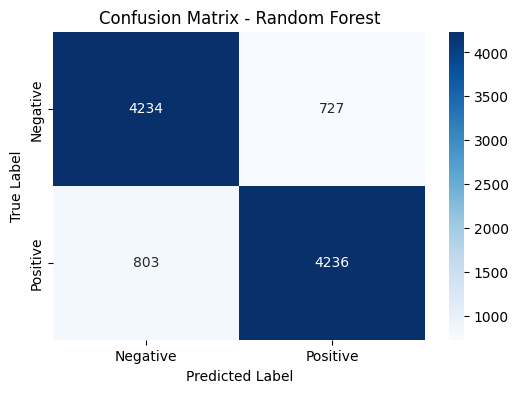

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


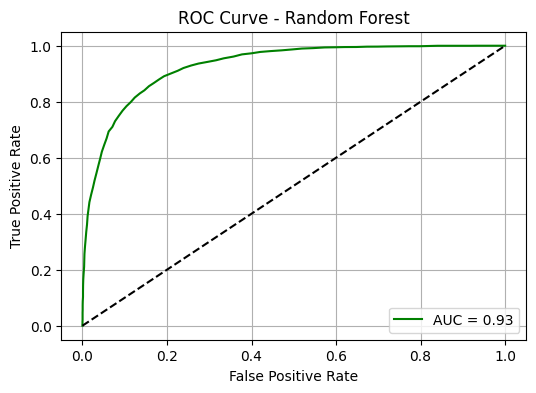

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_probs_rf)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.title('ROC Curve - Random Forest')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()


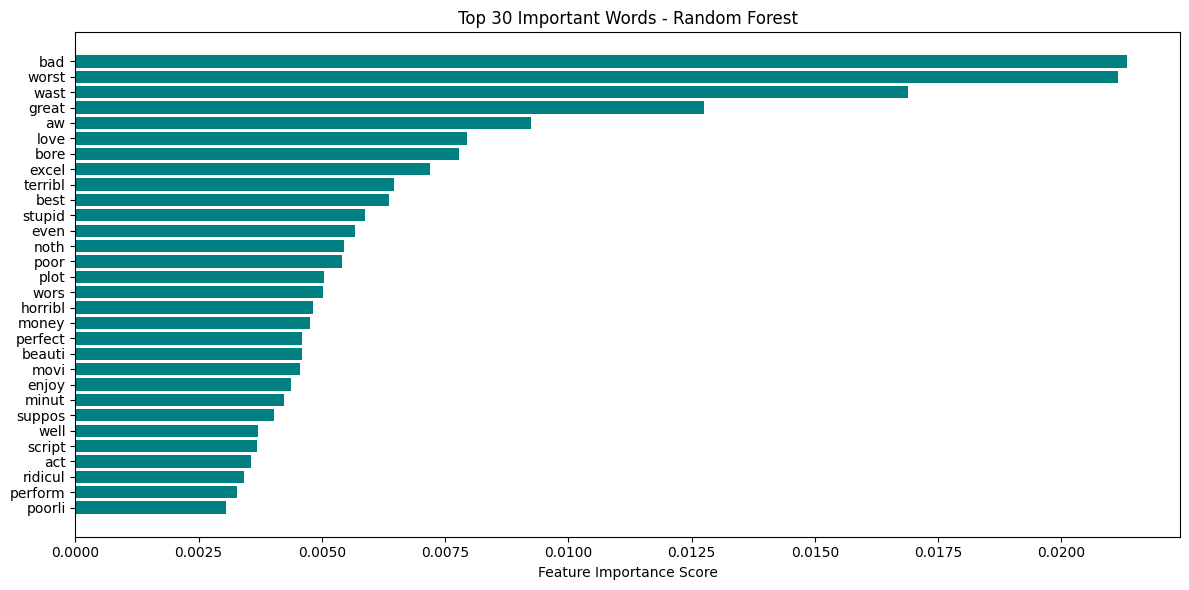

In [ ]:
import numpy as np

# Use 'vectorizer' instead of 'tfidf' to get feature names
feature_names = vectorizer.get_feature_names_out()
importances = rf_model.feature_importances_
indices = np.argsort(importances)[-30:]  # Top 30 features

plt.figure(figsize=(12,6))
plt.barh(range(len(indices)), importances[indices], align='center', color='teal')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Feature Importance Score')
plt.title('Top 30 Important Words - Random Forest')
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import classification_report

# Print classification report
print("📋 Classification Report - Random Forest:\n")
print(classification_report(y_test, y_pred_rf, target_names=['Negative', 'Positive']))


📋 Classification Report - Random Forest:

              precision    recall  f1-score   support

    Negative       0.84      0.85      0.85      4961
    Positive       0.85      0.84      0.85      5039

    accuracy                           0.85     10000
   macro avg       0.85      0.85      0.85     10000
weighted avg       0.85      0.85      0.85     10000



<ipython-input-22-4e860af94d45>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sizes = [df['sentiment'].value_counts()[0], df['sentiment'].value_counts()[1]]
<ipython-input-22-4e860af94d45>:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  sizes = [df['sentiment'].value_counts()[0], df['sentiment'].value_counts()[1]]


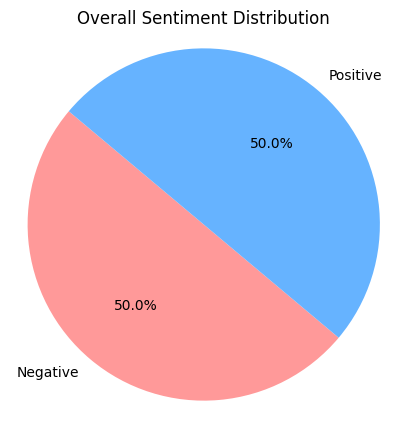

In [22]:
labels = ['Negative', 'Positive']
sizes = [df['sentiment'].value_counts()[0], df['sentiment'].value_counts()[1]]
colors = ['#FF9999','#66B3FF']

plt.figure(figsize=(5,5))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=140)
plt.title("Overall Sentiment Distribution")
plt.axis('equal')
plt.show()


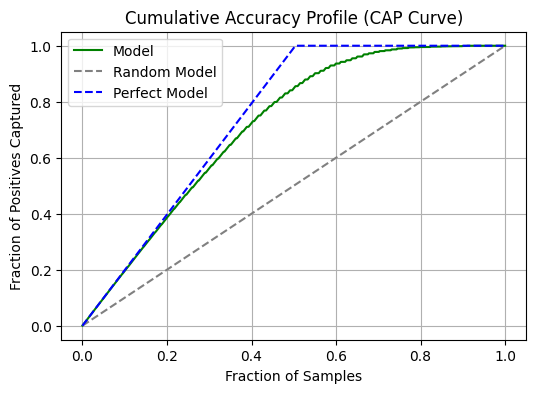

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# Sort by predicted probability
total = len(y_test)
class_1_count = sum(y_test)

y_true_sorted = [x for _, x in sorted(zip(y_probs_rf, y_test), reverse=True)]

cumulative = np.cumsum(y_true_sorted)
x = np.arange(total) / total
y = cumulative / class_1_count

# Plot
plt.figure(figsize=(6,4))
plt.plot(x, y, label="Model", color='green')
plt.plot([0, 1], [0, 1], '--', label="Random Model", color='gray')
plt.plot([0, class_1_count/total, 1], [0, 1, 1], '--', label="Perfect Model", color='blue')

plt.xlabel("Fraction of Samples")
plt.ylabel("Fraction of Positives Captured")
plt.title("Cumulative Accuracy Profile (CAP Curve)")
plt.legend()
plt.grid(True)
plt.show()


<ipython-input-27-237f9917040f>:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='True Label', y='Predicted Prob', data=df_probs, palette='coolwarm')


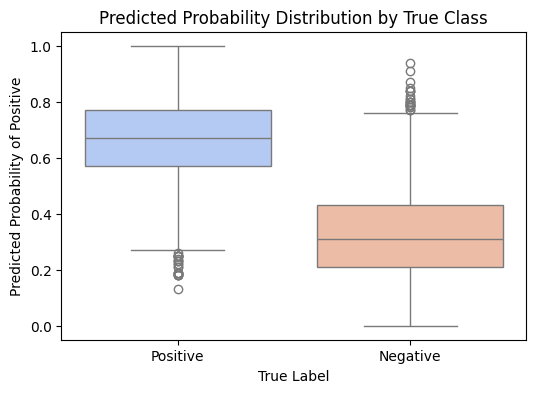

In [27]:
import seaborn as sns
import pandas as pd

# Create DataFrame for visualization
df_probs = pd.DataFrame({'True Label': y_test, 'Predicted Prob': y_probs_rf})
df_probs['True Label'] = df_probs['True Label'].map({0: 'Negative', 1: 'Positive'})

# Boxplot
plt.figure(figsize=(6,4))
sns.boxplot(x='True Label', y='Predicted Prob', data=df_probs, palette='coolwarm')
plt.title("Predicted Probability Distribution by True Class")
plt.ylabel("Predicted Probability of Positive")
plt.show()


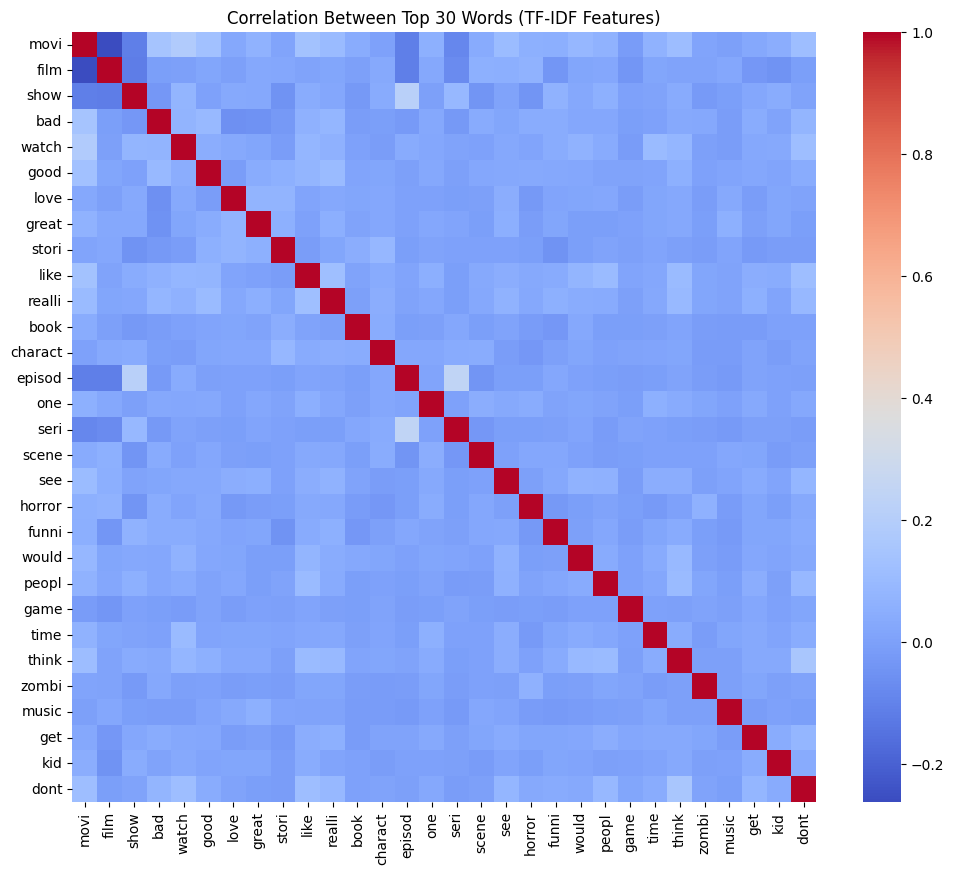

In [30]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Convert TF-IDF to DataFrame
# Use 'vectorizer' instead of 'tfidf' to get feature names
tfidf_df = pd.DataFrame(X_train_tfidf.toarray(), columns=vectorizer.get_feature_names_out())

# Select top 30 high variance features (words)
top_features = tfidf_df.var().sort_values(ascending=False).head(30).index
top_df = tfidf_df[top_features]

# Compute correlation
correlation_matrix = top_df.corr()

# Plot heatmap
plt.figure(figsize=(12,10))
sns.heatmap(correlation_matrix, cmap='coolwarm', annot=False)
plt.title("Correlation Between Top 30 Words (TF-IDF Features)")
plt.show()